In [ ]:
Alexis Root
### Project 01

In [ ]:
1) What is the salary range for a lead data science position, and what are the differences in the range
for an offshore employee? How are the changing company size and current economic conditions impacting 
the salary range for this?

2) How can we establish a clear, bias-free salary range that attracts top-tier talent while ensuring
internal equity as we scale from a small company to a mid-sized organization?
*2 Developed using Google Gen AI input, asked for a different way to ask the question and the refined
the best fitting version that AI gave

In [ ]:
I think the part that the AI mentioned about focusing on the current company scale and how it is growing
should be added to the overall question. A small company that is growing may benefit from hiring an 
employee with more overall experience to help drive the projects as they mentioned and eventually lead
a team, once the business grows further and they have the budget to hire more people. It may be more
costly to higher a lower cost employee with less experience and then have to hire someone else to 
suppliment what they can do.
I think the part about the offshore eployee is less relevant in regards to the salary range unless there
is a significant difference found, or unless the employee has significantly higher productivity. Having 
an employee closer to the company iteself is better in some ways since they would be in the same time zone
and could more easily travel as needed to the office. Other than that, the location of the employee seems
more or less irrelevant to me.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotnine as p9
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy.stats import ttest_ind

In [2]:
infile="project_1_data.csv"

comp_data_df=pd.read_csv(infile, index_col=0)

In [3]:
comp_data_df.dtypes

work_year              int64
experience_level      object
employment_type       object
job_title             object
salary                 int64
salary_currency       object
salary_in_usd          int64
employee_residence    object
remote_ratio           int64
company_location      object
company_size          object
dtype: object

In [17]:
#Updating Data Types
my_dtypes = {
    "experience_level": "category",
    "work_year": int,
    "employment_type": "category",
    "job_title": "category",
    "salary_currency": "category",
    "employee_residence": "category",
    "company_location": "category",
    "company_size": "category",
}

infile = "project_1_data.csv"
comp_data_df = pd.read_csv(infile, dtype=my_dtypes, index_col=0)
# Ordering experience level
comp_data_df["experience_level"] = pd.Categorical(
    comp_data_df["experience_level"].map({
        "EN": "Entry Level",
        "MI": "Mid Level",
        "SE": "Senior Level",
        "EX": "Executive Level"
    }),
    categories=[
        "Entry Level",
        "Mid Level",
        "Senior Level",
        "Executive Level"
    ],
    ordered=True
)
# Ordering Remote
comp_data_df["remote_ratio"] = pd.Categorical(
    comp_data_df["remote_ratio"].map({
        0: "Onsite",
        50: "Hybrid",
        100: "Fully Remote",
    }),
    categories=[
        "Onsite",
        "Hybrid",
        "Fully Remote"
    ],
    ordered=True
)
# Ordering comapny size (S, M, L)
comp_data_df["company_size"] = pd.Categorical(
    comp_data_df["company_size"].map({
        "S": "Small",
        "M": "Medium",
        "L": "Large"
    }),
    categories=[
        "Small",
        "Medium",
        "Large"
    ],
    ordered=True
)

In [18]:
comp_data_df.dtypes

work_year                int64
experience_level      category
employment_type       category
job_title             category
salary                   int64
salary_currency       category
salary_in_usd            int64
employee_residence    category
remote_ratio          category
company_location      category
company_size          category
dtype: object

In [19]:
type(comp_data_df)

pandas.core.frame.DataFrame

In [20]:
comp_data_df.head

<bound method NDFrame.head of      work_year experience_level employment_type                   job_title  \
0         2020        Mid Level              FT              Data Scientist   
1         2020     Senior Level              FT  Machine Learning Scientist   
2         2020     Senior Level              FT           Big Data Engineer   
3         2020        Mid Level              FT        Product Data Analyst   
4         2020     Senior Level              FT   Machine Learning Engineer   
..         ...              ...             ...                         ...   
602       2022     Senior Level              FT               Data Engineer   
603       2022     Senior Level              FT               Data Engineer   
604       2022     Senior Level              FT                Data Analyst   
605       2022     Senior Level              FT                Data Analyst   
606       2022        Mid Level              FT                AI Scientist   

     salary salary_cu

In [21]:
comp_data_df.describe()
#work_year- data range is from 2020-2022. Good to know, summary data hear other than min/max values are irrelevant.
#salary- Numbers are all over the place because the salaries in this column are all listed in different currencies.
#salary_in_usd- min=0 is concerning there should be no $0 salary. Row needs to be removed for analysis.
#remote ratio- max= full time remote or onsite, min= onsite or fully remote, mean being lower than median is at 100 suggests that it's skewed.
#No other variables listed on table because they are defined as category types not numbers.

,work_year,salary,salary_in_usd
count,607.000000,6.070000e+02,607.000000
mean,2021.405272,3.240001e+05,112297.869852
std,0.692133,1.544357e+06,70957.259411
min,2020.000000,4.000000e+03,2859.000000
25%,2021.000000,7.000000e+04,62726.000000
50%,2022.000000,1.150000e+05,101570.000000
75%,2022.000000,1.650000e+05,150000.000000
max,2022.000000,3.040000e+07,600000.000000


In [22]:
comp_data_df.info()
#no null values confirmed, data types are set as I need

<class 'pandas.core.frame.DataFrame'>
Index: 607 entries, 0 to 606
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   work_year           607 non-null    int64   
 1   experience_level    607 non-null    category
 2   employment_type     607 non-null    category
 3   job_title           607 non-null    category
 4   salary              607 non-null    int64   
 5   salary_currency     607 non-null    category
 6   salary_in_usd       607 non-null    int64   
 7   employee_residence  607 non-null    category
 8   remote_ratio        607 non-null    category
 9   company_location    607 non-null    category
 10  company_size        607 non-null    category
dtypes: category(8), int64(3)
memory usage: 32.4 KB


In [23]:
comp_data_df.loc[comp_data_df["employment_type"] == "FT",
                 ["salary_in_usd", "remote_ratio", "experience_level"]].groupby(["experience_level", "remote_ratio"], observed=True).mean()
#Salaries are going up as you move upwards in experience level as expected. People working with 100 remote ratio are being paid more than the other categories but it's not a clear relationship between salaries and remote ratio across experience level.

salary_in_usd
experience_level remote_ratio               
Entry Level      Onsite         57666.357143
                 Hybrid         63897.619048
                 Fully Remote   66885.454545
Mid Level        Onsite         83259.327273
                 Hybrid         80486.692308
                 Fully Remote   93685.794643
Senior Level     Onsite        141177.759259
                 Hybrid         95250.888889
                 Fully Remote  144428.776650
Executive Level  Onsite        158948.666667
                 Hybrid        143175.400000
                 Fully Remote  210321.764706

In [24]:
comp_data_df.loc[comp_data_df["employment_type"] == "FT",
                 ["salary_in_usd", "company_size", "experience_level"]].groupby(["experience_level", "company_size"], observed=True).mean()
#Same trend in salaries increasing as experience level increases. You see larger gaps in what employees are being paid between small and large companies for exeutive level employees and other senior employees than is seen for entry level workers.

salary_in_usd
experience_level company_size               
Entry Level      Small          69005.200000
                 Medium         52131.730769
                 Large          71842.285714
Mid Level        Small          51159.379310
                 Medium         91700.178947
                 Large          97755.048780
Senior Level     Small         118694.666667
                 Medium        137992.978378
                 Large         147591.013889
Executive Level  Small          93964.000000
                 Medium        178241.750000
                 Large         221942.181818

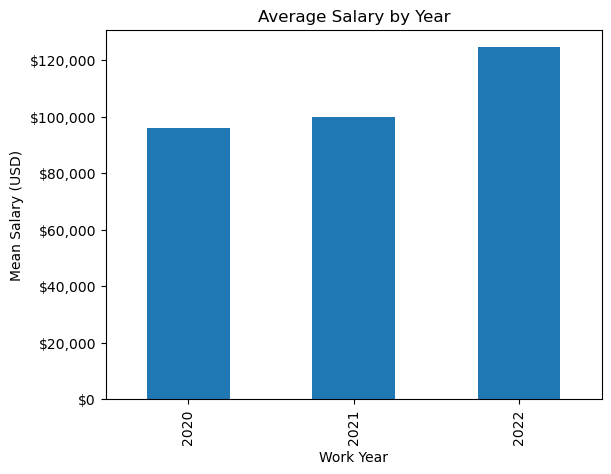

In [25]:
#Graph for Work Year variable
ax = comp_data_df.groupby("work_year")["salary_in_usd"].mean().plot(kind="bar")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))# Formats y-axis as dollars
plt.title("Average Salary by Year")
plt.xlabel("Work Year")
plt.ylabel("Mean Salary (USD)")
plt.show()
#salaries are going up year after year as expected, salaries did go up more between 2021-2022

C:\Users\Lex\AppData\Local\Temp\ipykernel_15692\1345826130.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


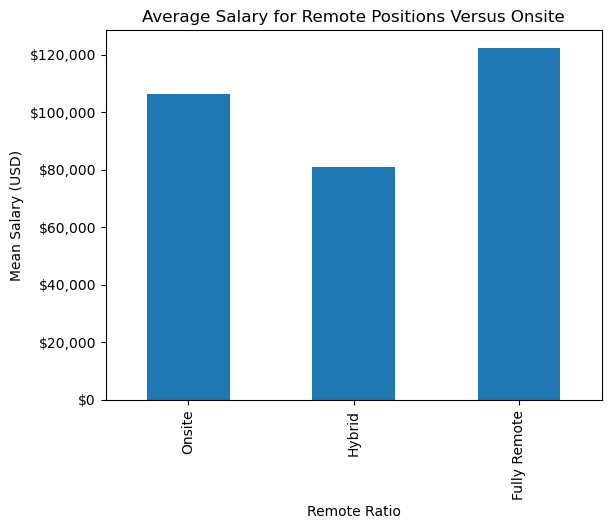

In [26]:
#Graph for Remote- Ratio variable
ax = comp_data_df.groupby("remote_ratio")["salary_in_usd"].mean().plot(kind="bar")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}')) # Formats y-axis as dollars
plt.title("Average Salary for Remote Positions Versus Onsite")
plt.xlabel("Remote Ratio")
plt.ylabel("Mean Salary (USD)")
plt.show()
#This is not what I would expect, there could be other factors inpacting this. Such as different jobs are more suited for fully remote work and pay higher for it than other jobs would.
# It looks like a 100% remote position pays the highest over a 0% remote position.
#I would expect 50% to bethe middle salary range but it is the lowest salary range.

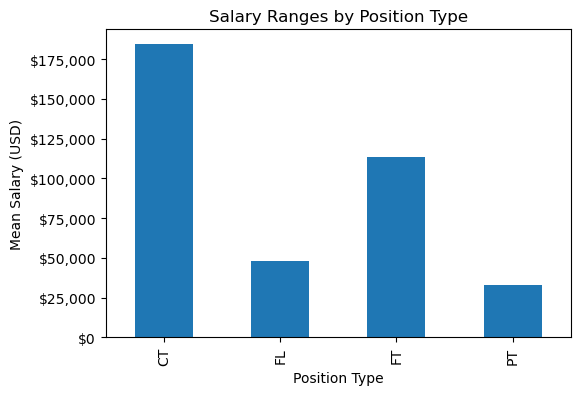

In [27]:
#Graphing the mean salaries for different employee types- FT/PT/FL/contractor
mean_salary = comp_data_df.groupby("employment_type", observed= True)["salary_in_usd"].mean()
fig, ax = plt.subplots(figsize=(6,4))
mean_salary.plot(kind="bar", ax=ax)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}')) # Format y-axis as dollars
ax.set_title("Salary Ranges by Position Type")
ax.set_xlabel("Position Type")
ax.set_ylabel("Mean Salary (USD)")
plt.show()
#Contractors have the highest average salary compared to a full time position. Based on what this suggests, it would not be wise to give the job to a contracted worker over hiring a full time employee.
#FL workers are only hired on for one project at a time, so their salary being low makes since
#PT worker salaries being low makes sense although under $50K seems a bit low depending on the position they are working. They are even a lower salary height than the FL employees which seems odd to me.
#Plan to not include FL/PT/Contractors in calculations since PT/FL is not what we are looking for and contractors are more expensive over hiring a full time employee.

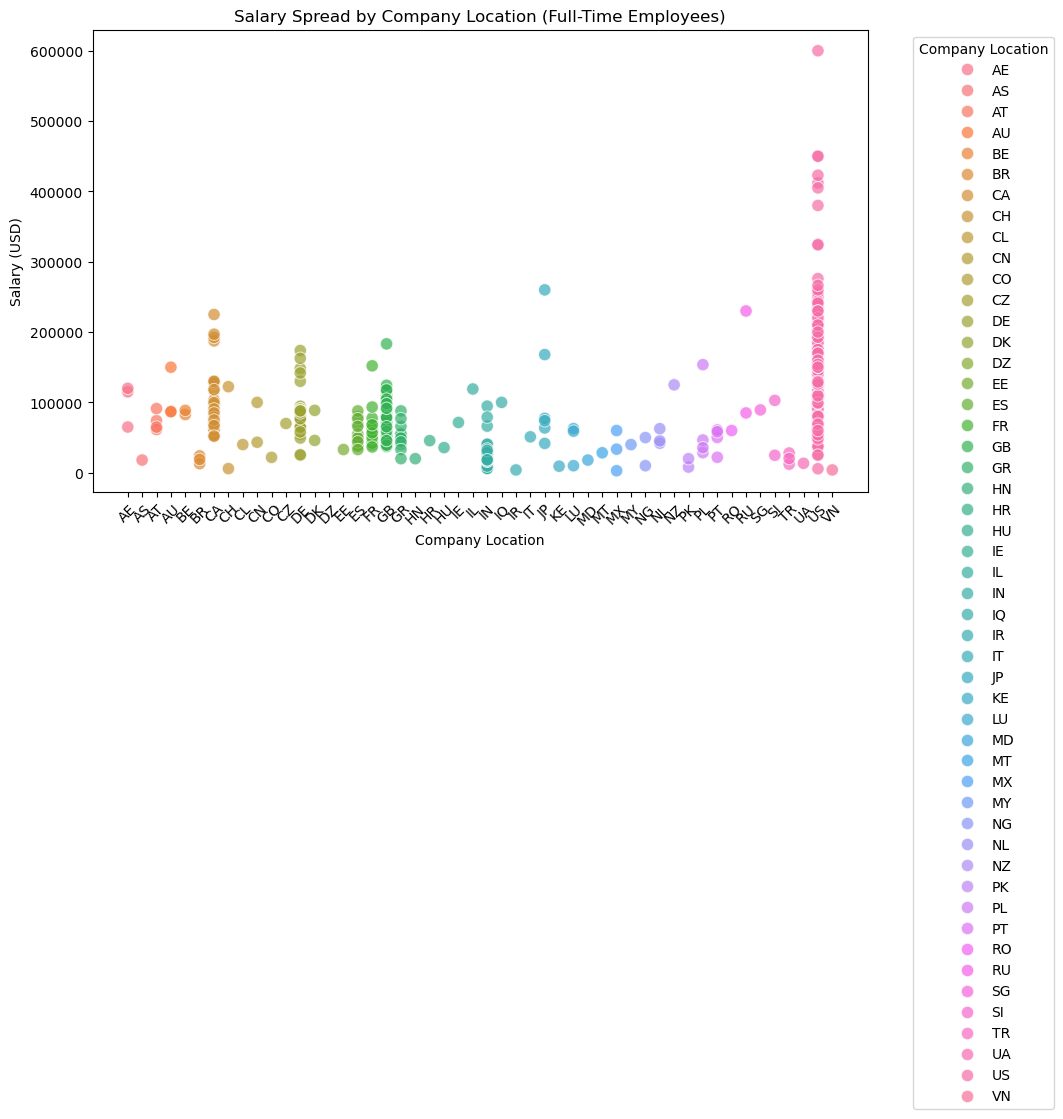

In [18]:
#Scatterplot for USD salary differences across different company locations
df = comp_data_df[comp_data_df['employment_type'] == 'FT']
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='company_location',
    y='salary_in_usd',
    hue='company_location', # different color per location
    alpha=0.7, #controls transparency of point, 1=opaque, 0=invisible
    s=80 # size of points
)
plt.title('Salary Spread by Company Location (Full-Time Employees)')
plt.xlabel('Company Location')
plt.ylabel('Salary (USD)')
plt.xticks(rotation=45)
plt.legend(title='Company Location', bbox_to_anchor=(1.05, 1), loc='upper left') #Moving legend so it's not center of graph
plt.show()
#Hard to decipher even with the points having different colors; US is a pinkish color but other countries have a similar color
#Looks like most countries have lower salaries in USD but hard to discern from culmination of x-axis labels

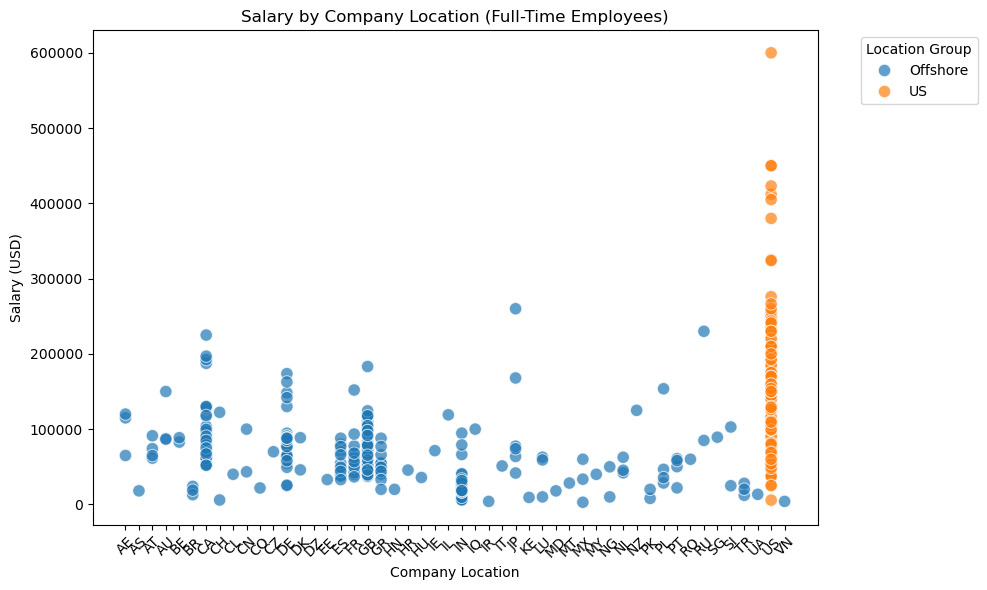

In [19]:
#Seperating US from all other countries to see how scaterplot looks compared to the one made above.
# Create a US vs Offshore grouping
comp_data_df['location_group'] = comp_data_df['company_location'].apply(lambda x: 'US' if x == 'US' else 'Offshore')
#loops through each salary_currency listing, adds either US/offshore to new col currency "group"
df = comp_data_df[comp_data_df['employment_type'] == 'FT']
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='company_location',
    y='salary_in_usd',
    hue='location_group', # US vs Offshore points have differennt colors
    alpha=0.7, #controls transparency of point, 1=opaque, 0=invisible
    s=80 #size of plotted points
)
plt.title('Salary by Company Location (Full-Time Employees)')
plt.xlabel('Company Location')
plt.ylabel('Salary (USD)')
plt.xticks(rotation=45) #rotate x names for visibilty
plt.legend(title='Location Group', bbox_to_anchor=(1.05, 1), loc='upper left') #move legend off center
plt.tight_layout()
plt.show()
#Easier to see the US points, it's iteresting how a majrity of the points still fall within the general range of the other countries but we have the few points scattered throughout the top half of the graph for the highest paid employees.
#This suggests to me that there could be a cost benefit to hiring an offshore employee.

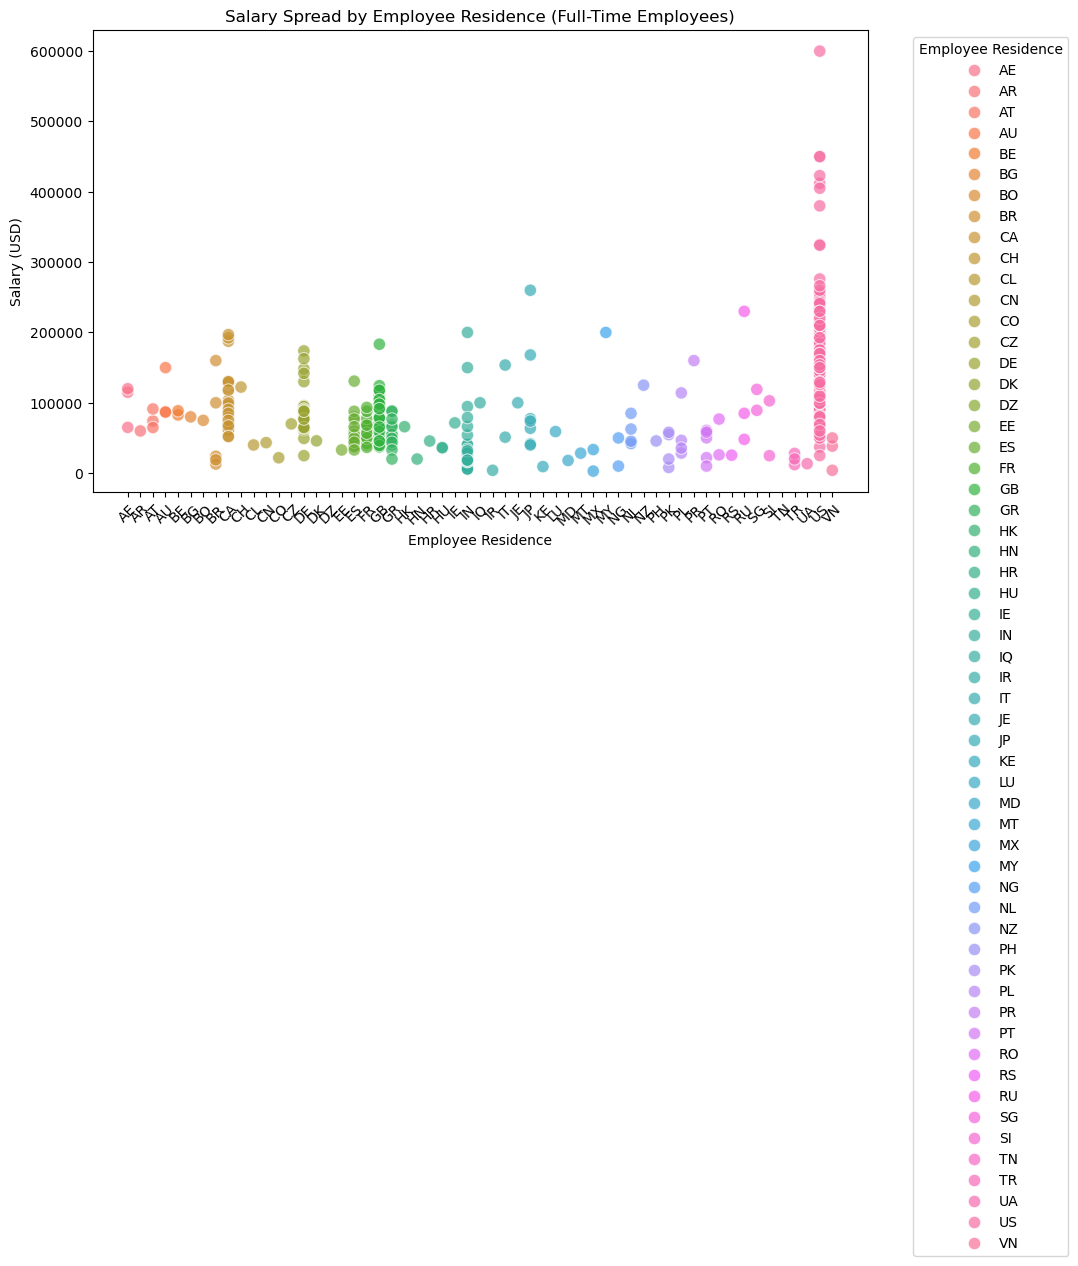

In [20]:
#Scatterplot for USD salary differences across different employee residence locations
df = comp_data_df[comp_data_df['employment_type'] == 'FT']
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='employee_residence',
    y='salary_in_usd',
    hue='employee_residence', # different color per location
    alpha=0.7, #controls transparency of point, 1=opaque, 0=invisible
    s=80 # size of points
)
plt.title('Salary Spread by Employee Residence (Full-Time Employees)')
plt.xlabel('Employee Residence')
plt.ylabel('Salary (USD)')
plt.xticks(rotation=45) #rotate x names for visibilty
plt.legend(title='Employee Residence', bbox_to_anchor=(1.05, 1), loc='upper left') #move legend off center
plt.show()
#Results are very simialr to the company location graph. 
#Despite rotating x-axis lables, still very hard to read. Not a great graph to use.

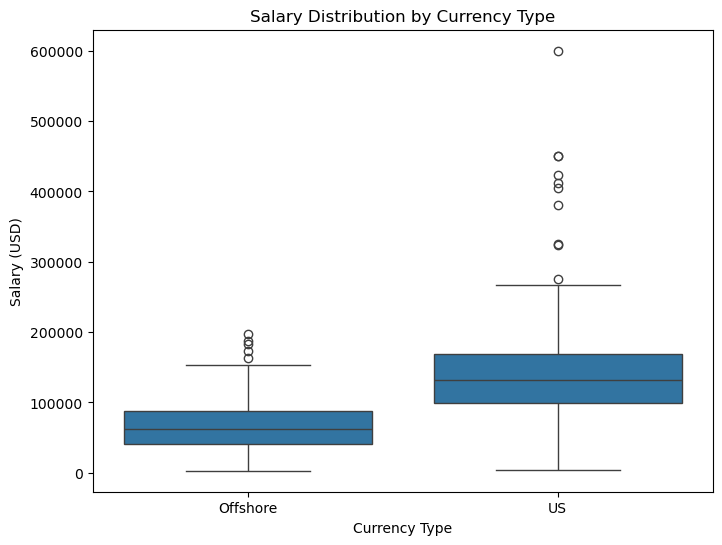

In [45]:
#Salary Currency
comp_data_df['currency_group'] = comp_data_df['salary_currency'].apply(lambda x: 'US' if x == 'USD' else 'Offshore')
df = comp_data_df[comp_data_df['employment_type'] == 'FT']
plt.figure(figsize=(8,6))
sns.boxplot(
    data=df,
    x="currency_group",
    y="salary_in_usd",
)
plt.title("Salary Distribution by Currency Type")
plt.xlabel("Currency Type")
plt.ylabel("Salary (USD)")
plt.show()
#Salaries in USD are higher for salaries paid in USD currency versus salaries paid as offshore. Will need a T-Test to prove if there is a significant differnce between the two groups.

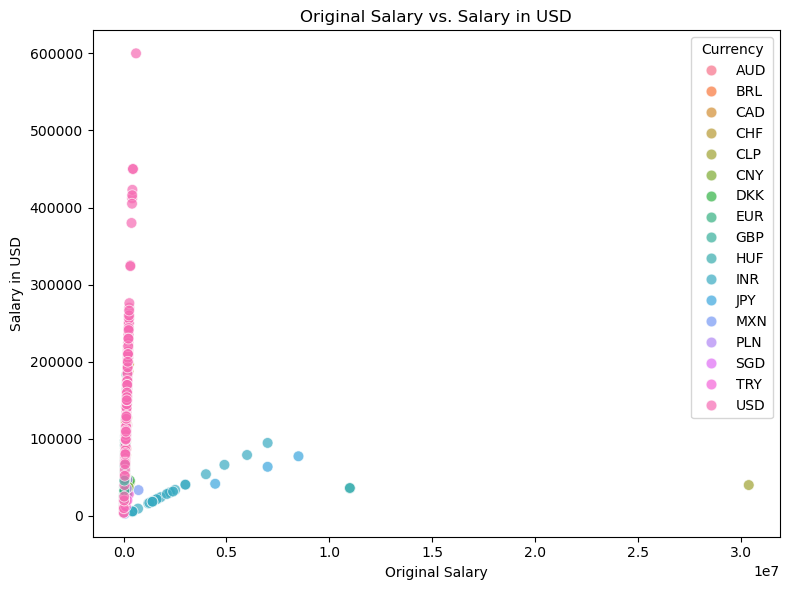

In [103]:
#Scatterplot to show relationship between salary and salary in USD
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=comp_data_df,
    x='salary',
    y='salary_in_usd',
    hue='salary_currency',
    alpha=0.7,
    s=60
)
plt.title('Original Salary vs. Salary in USD')
plt.xlabel('Original Salary')
plt.ylabel('Salary in USD')
plt.legend(title='Currency')
plt.tight_layout()
plt.show()
#Hard to see much from this version of the groph, the points are all clustered together on the left.

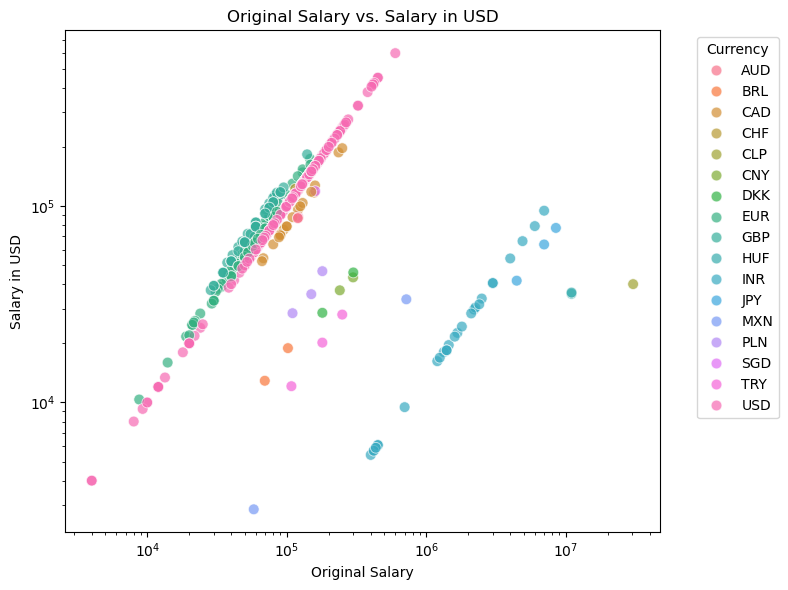

In [22]:
#Scatterplot to show relationship between salary and salary in USD
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=comp_data_df,
    x='salary',
    y='salary_in_usd',
    hue='salary_currency',
    alpha=0.7,
    s=60
)
plt.title('Original Salary vs. Salary in USD')
plt.xlabel('Original Salary')
plt.ylabel('Salary in USD')
plt.xscale('log') #transformation added to help with visibility
plt.yscale('log') #transformation added to help with visibility
plt.legend(title ='Currency', bbox_to_anchor = (1.05, 1), loc = 'upper left') #moved legend off center of graph
plt.tight_layout()
plt.show()
#Salaries are higher in USD, the salaries in USD originally go up higher right on the graph than all other points.
#There is a good cluster of countries aligned with a similar line as the US one shown belwo, with some countries falling further right on the graph for higher offshore salasies with lower USD salaries.

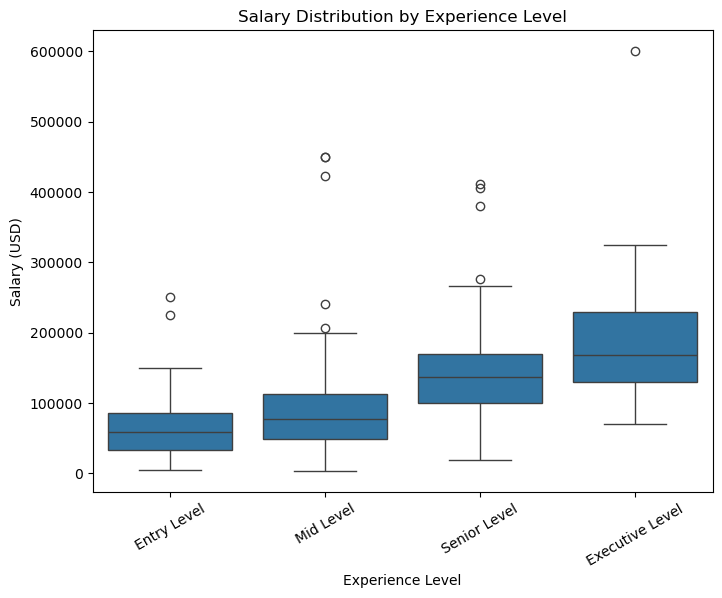

In [23]:
#Graph of Experience Level Variable
df = comp_data_df[comp_data_df["employment_type"] == "FT"]  # only full-time employees
plt.figure(figsize=(8,6))
sns.boxplot(
    data=df,
    x="experience_level",
    y="salary_in_usd",
)
plt.title("Salary Distribution by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Salary (USD)")
plt.xticks(rotation=30) #rotated x-axis for readability, 30 degrees
plt.show()
#There's quite a few outliers here, could be between the different job titles included in the dataset, they aren't all the same and likely have different salary ranges
#Salary goes up by experience as expected
#Executive level employees have the widest range of salaries within their 25-75% average, this can be seen by the box shown on the plot for their category it is twice as long as the entry level boxplot.

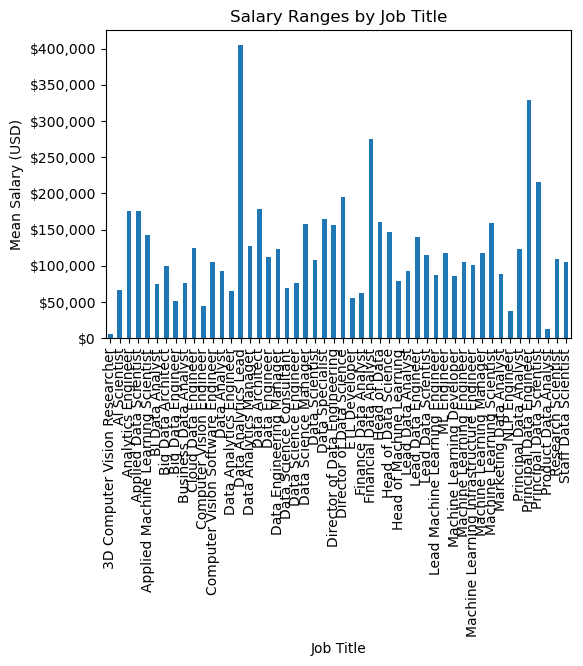

In [24]:
#Initial Job Title Graph
mean_salary = comp_data_df.groupby("job_title", observed= True)["salary_in_usd"].mean()
fig, ax = plt.subplots(figsize=(6,4))
mean_salary.plot(kind="bar", ax=ax)
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}')) # Format y-axis as dollars
ax.set_title("Salary Ranges by Job Title")
ax.set_xlabel("Job Title")
ax.set_ylabel("Mean Salary (USD)")
plt.xticks(rotation=90) #rotates words on x-axis lables for visibility
plt.show()
#This is unreadable, not a lot can be gained from this graph
#There are too many job titles, they need to be grouped together to narrow down how many different job titles we're working with
#May be able to filter out irrelevant job titles

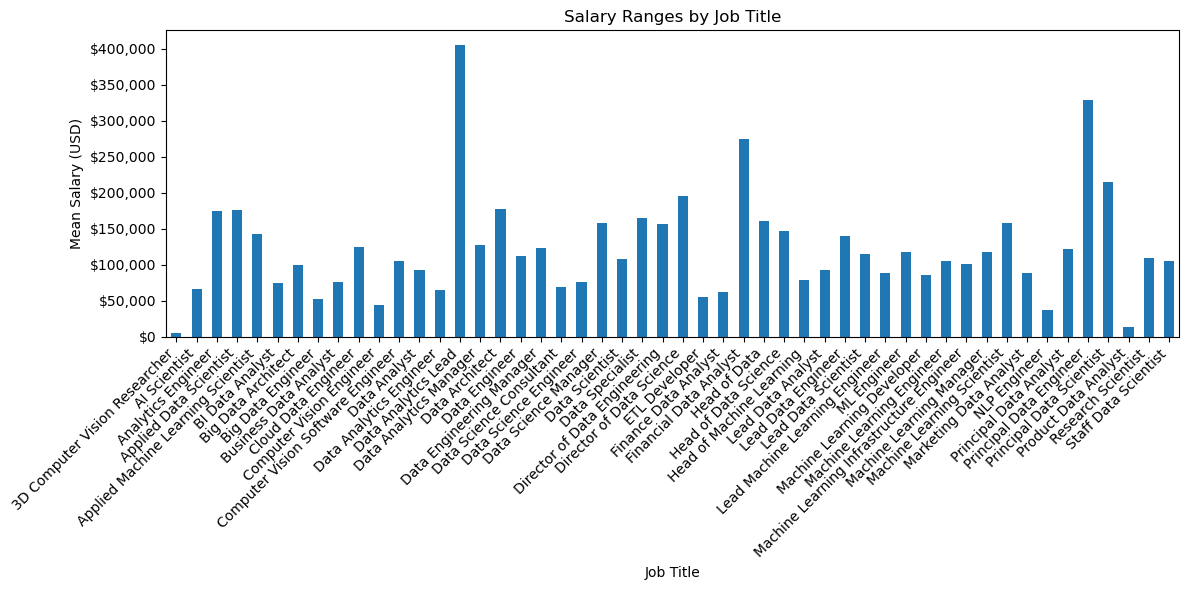

In [47]:
#Improve previous graph for wider axis
mean_salary = comp_data_df.groupby("job_title", observed=True)["salary_in_usd"].mean()
# Make figure wider
fig, ax = plt.subplots(figsize=(12,6))  # Wider and taller
mean_salary.plot(kind="bar", ax=ax)
# Format y-axis as dollars
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
ax.set_title("Salary Ranges by Job Title")
ax.set_xlabel("Job Title")
ax.set_ylabel("Mean Salary (USD)")
plt.xticks(rotation=45, ha='right')  # Rotate 45 degrees and align right
plt.tight_layout()  # Ensures everything fits without overlap
plt.show()

In [28]:
#Grouping Job Titles- used AI (chat GPT) to take list of all 50 job titles in data set and convert them to groups. Refined suggested groups to better fit what I thought made the most sense.
#Also used AI to help speed along process of writing out the individual job iotles for each group to bring code together
title_grouped_comp_data = comp_data_df.copy()
# Define conditions for job groups
conditions = [
    title_grouped_comp_data['job_title'].str.contains(
        "DATA SCIENTIST|LEAD DATA SCIENTIST|PRINCIPAL DATA SCIENTIST|STAFF DATA SCIENTIST|APPLIED DATA SCIENTIST|DATA SCIENCE CONSULTANT|DATA SPECIALIST",
        case=False, regex=True
    ),
    title_grouped_comp_data['job_title'].str.contains(
        "MACHINE LEARNING|ML ENGINEER|AI SCIENTIST|NLP ENGINEER|COMPUTER VISION|APPLIED MACHINE LEARNING",
        case=False, regex=True
    ),
    title_grouped_comp_data['job_title'].str.contains(
        "DATA ANALYST|PRODUCT DATA ANALYST|BUSINESS DATA ANALYST|MARKETING DATA ANALYST|FINANCIAL DATA ANALYST|BI DATA ANALYST|PRINCIPAL DATA ANALYST|DATA ANALYTICS LEAD",
        case=False, regex=True
    ),
    title_grouped_comp_data['job_title'].str.contains(
        "DATA ENGINEER|LEAD DATA ENGINEER|DATA SCIENCE ENGINEER|DATA ARCHITECT|PRINCIPAL DATA ENGINEER|BIG DATA|CLOUD DATA ENGINEER|ETL DEVELOPER|ANALYTICS ENGINEER",
        case=False, regex=True
    )
]

# Job grouping labels
choices = [
    "Data Scientist",
    "Machine Learning / AI Engineer",
    "Data Analyst",
    "Data Engineer / Architect"
]
# Creating new column for job groups
title_grouped_comp_data['job_group'] = np.select(conditions, choices, default="Other")
title_grouped_comp_data[['job_title', 'job_group']].head(10)

,job_title,job_group
0,Data Scientist,Data Scientist
1,Machine Learning Scientist,Machine Learning / AI Engineer
2,Big Data Engineer,Data Engineer / Architect
3,Product Data Analyst,Data Analyst
4,Machine Learning Engineer,Machine Learning / AI Engineer
5,Data Analyst,Data Analyst
6,Lead Data Scientist,Data Scientist
7,Data Scientist,Data Scientist
8,Business Data Analyst,Data Analyst
9,Lead Data Engineer,Data Engineer / Architect


C:\Users\Lex\AppData\Local\Temp\ipykernel_5444\4257362927.py:3: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead


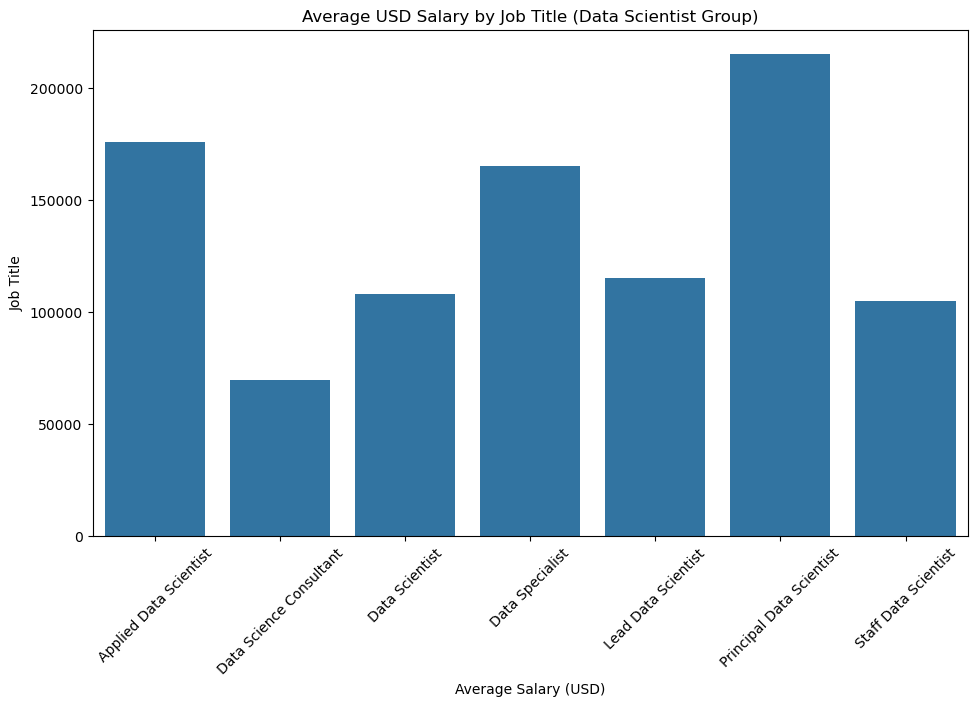

In [26]:
#New Graph for Job Title, filtering to job group data scientist
ds_df = title_grouped_comp_data[title_grouped_comp_data['job_group'] == "Data Scientist"].copy()
if pd.api.types.is_categorical_dtype(ds_df['job_title']): 
    ds_df['job_title'] = ds_df['job_title'].cat.remove_unused_categories() #drops excess categories
salary_means = ds_df.groupby('job_title', observed=True)['salary_in_usd'].mean().sort_values(ascending=False).reset_index() #calc mean
plt.figure(figsize=(10,6))
sns.barplot(
    data=salary_means, #using calc mean from above
    y='salary_in_usd',
    x='job_title',
)
plt.title('Average USD Salary by Job Title (Data Scientist Group)')
plt.xlabel('Average Salary (USD)')
plt.ylabel('Job Title')
plt.tight_layout()
plt.xticks(rotation=45)
plt.show()
#Much easier to read, it makes sense that positions starting with words like "Principal" and "Lead" would
#make more money, they are positions we would expect someone to have more experience.

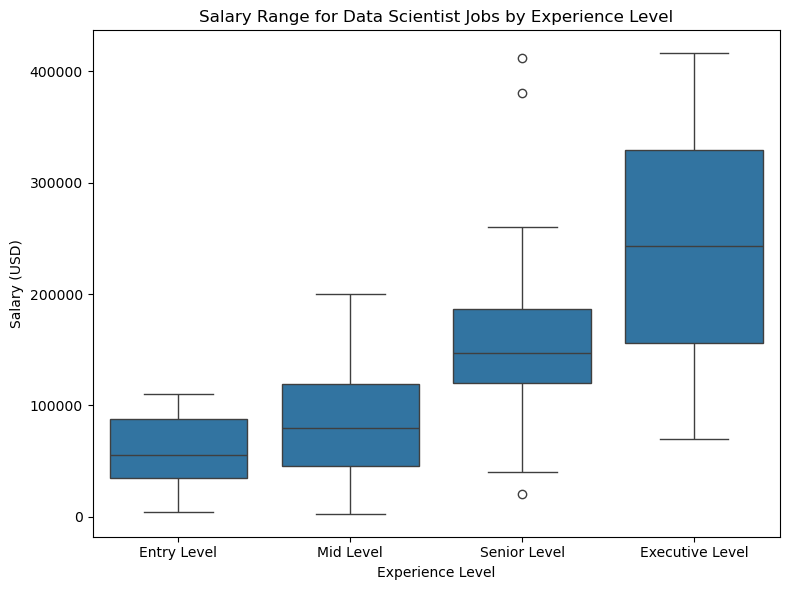

In [27]:
# Filtering to Data Scientist group, full-time employees, and employees without a $0 salary
ds_df = title_grouped_comp_data[
    (title_grouped_comp_data['job_group'] == "Data Scientist") &
    (~title_grouped_comp_data['experience_level'].isna()) &
    (title_grouped_comp_data['salary_in_usd'] > 0)
].copy()
plt.figure(figsize=(8,6))
sns.boxplot(
    data=ds_df,
    x='experience_level',
    y='salary_in_usd',
)
plt.title('Salary Range for Data Scientist Jobs by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Salary (USD)')
plt.tight_layout()
plt.show()
#Seeing significantly less outliers on this graph than I 've seen with the graphs prior, this is a good sign
#We probably don't need an executive employee for ths position but grpah shows the options for salary ranges we could give the CEO to decide what experience level they want to hire for.
#Based on CEO's prompt we would want someone mid level to senior level for this position but not entry level because no one else will be hired on to support them.

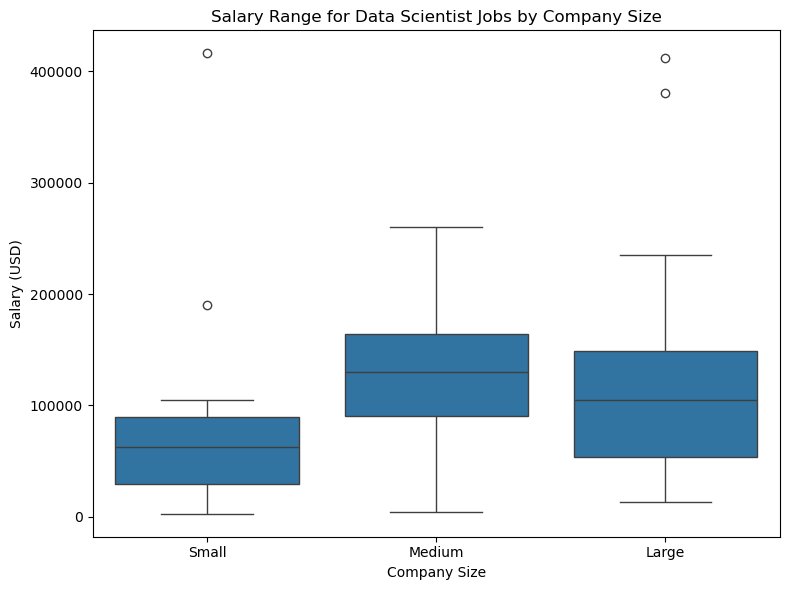

In [28]:
#Graph for average data scientist salary based on company size
# Filtering to Data Scientist group, full-time employees, and employees without a $0 salary
ds_df = title_grouped_comp_data[
    (title_grouped_comp_data['job_group'] == "Data Scientist") &
    (~title_grouped_comp_data['company_size'].isna()) &
    (title_grouped_comp_data['salary_in_usd'] > 0)
].copy()
plt.figure(figsize=(8,6))
sns.boxplot(
    data=ds_df,
    x='company_size',
    y='salary_in_usd',
)
plt.title('Salary Range for Data Scientist Jobs by Company Size')
plt.xlabel('Company Size')
plt.ylabel('Salary (USD)')
plt.tight_layout()
plt.show()
#Still not a consistent difference between s, m, l like we woukd expect. Medium companies have the highest salary range in this dataset.
#This should not be a major consideration in our reccomendation. The range for a smaller company is lower than others but since we are a rapidly growing company this is not as impactful.
#There's a few outliers here, this along with the pattern shown here suggests there's something missing or not quite right with this data, maybe we just need more data. Or perhaps this discrepancy has to do with how the data was taken. What were the requirements for being a small versus medium, or medium versus large company? Scale tends to be relative unless explicitely defined.

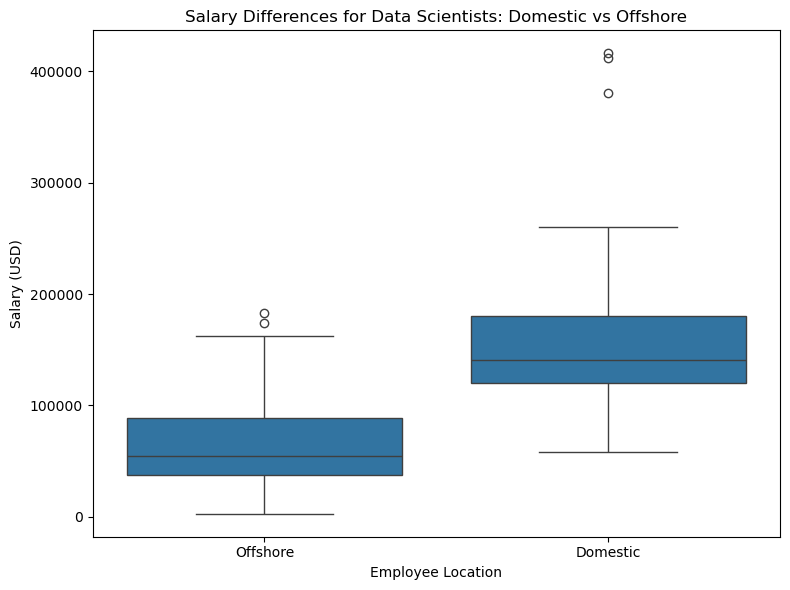

In [29]:
# Graph for domestic versus offshore enployee salaries for data scientist grouping
ds_df = title_grouped_comp_data[
    (title_grouped_comp_data['job_group'] == "Data Scientist") &
    (~title_grouped_comp_data['salary_in_usd'].isna()) &
    (title_grouped_comp_data['salary_in_usd'] > 0)
].copy()
# Create domestic vs offshore variable
ds_df['location_group'] = ds_df['employee_residence'].apply(lambda x: 'Domestic' if x == 'US' else 'Offshore')
#loops through each salary_currency listing, adds either US/offshore to new col currency "group"
plt.figure(figsize=(8,6))
sns.boxplot(
    data=ds_df,
    x='location_group',
    y='salary_in_usd',
)
plt.title('Salary Differences for Data Scientists: Domestic vs Offshore')
plt.xlabel('Employee Location')
plt.ylabel('Salary (USD)')
plt.tight_layout()
plt.show()
#Domestic Employees cost more than offshore employees. The domestic lower end whisker starts at the median for the offshore emplyee average salary.
#It would be more cost efficient for our CEO to hire an offshore employee.
#Should reccomend they hire an offshore employee with a higher experience level if she is ok with remote work.
#Still a couple of outliers

In [30]:
#Exploring remaining outliers
ds_df = title_grouped_comp_data[
    (title_grouped_comp_data['job_group'] == "Data Scientist") &
    (title_grouped_comp_data['salary_in_usd'] > 0)
].copy()
# Create Domestic vs Offshore group variable
ds_df['location_group'] = ds_df['employee_residence'].apply(lambda x: 'Domestic' if x == 'US' else 'Offshore')
#loops through each salary_currency listing, adds either US/offshore to new col currency "group"
# Function to find outliers in a group, uses IQR formula
def find_outliers(group, column='salary_in_usd'):
    Q1 = group[column].quantile(0.25)
    Q3 = group[column].quantile(0.75)
    IQR = Q3 - Q1
    outliers = group[
        (group[column] < (Q1 - 1.5 * IQR)) |
        (group[column] > (Q3 + 1.5 * IQR))
    ]
    return outliers
# Applying to each location group
outliers_by_location = ds_df.groupby('location_group', group_keys=False).apply(find_outliers)
print(outliers_by_location)
#captured all the outliers in this search and they don't look like typos. Most are for higher ranking employees but there is one mid-level employee shown as an outlier.

     work_year experience_level employment_type                 job_title  \
63        2020     Senior Level              FT            Data Scientist   
225       2021  Executive Level              CT  Principal Data Scientist   
519       2022     Senior Level              FT    Applied Data Scientist   
257       2021     Senior Level              FT  Principal Data Scientist   
474       2022        Mid Level              FT            Data Scientist   

     salary salary_currency  salary_in_usd employee_residence  remote_ratio  \
63   412000             USD         412000                 US           100   
225  416000             USD         416000                 US           100   
519  380000             USD         380000                 US           100   
257  147000             EUR         173762                 DE           100   
474  140000             GBP         183228                 GB             0   

    company_location company_size location_group currency_grou

C:\Users\Lex\AppData\Local\Temp\ipykernel_5444\1682948400.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


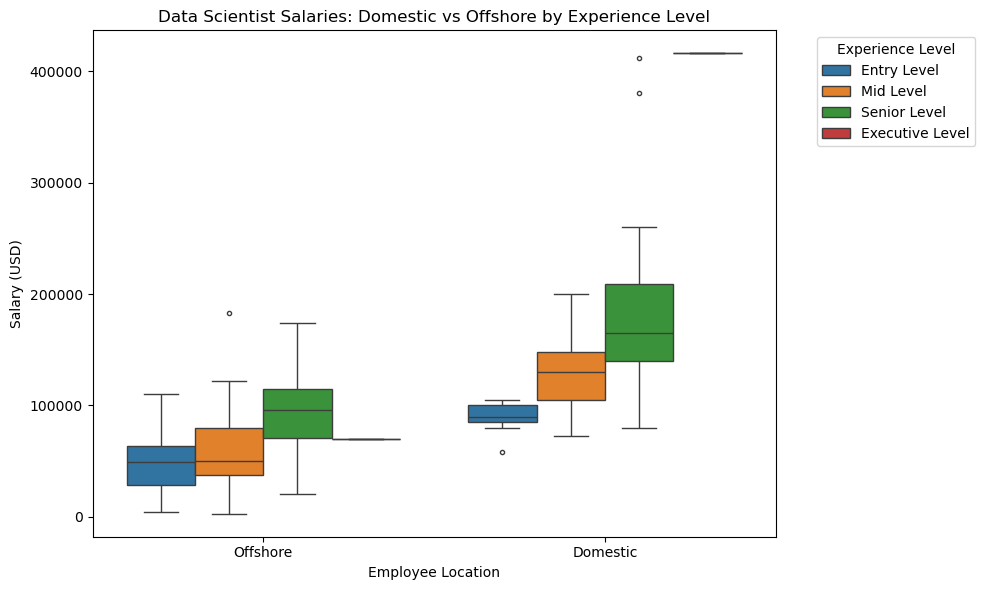

In [31]:
#More refined table to add experience levels to better compare salary ranges
ds_df = title_grouped_comp_data[
    (title_grouped_comp_data['job_group'] == "Data Scientist") &
    (title_grouped_comp_data['salary_in_usd'] > 0)
].copy()
# Create Domestic vs Offshore group variable
ds_df['location_group'] = ds_df['employee_residence'].apply(lambda x: 'Domestic' if x == 'US' else 'Offshore')
#loops through each salary_currency listing, adds either US/offshore to new col currency "group"
plt.figure(figsize=(10,6))
sns.boxplot(
    data=ds_df,
    x='location_group',
    y='salary_in_usd',
    hue='experience_level', #color by experience levels
    fliersize=3,     # Outlier dot size
    linewidth=1
)
plt.title('Data Scientist Salaries: Domestic vs Offshore by Experience Level')
plt.xlabel('Employee Location')
plt.ylabel('Salary (USD)')
plt.legend(title='Experience Level', bbox_to_anchor=(1.05, 1), loc='upper left')  # move legend off center
plt.tight_layout()
plt.show()
#Both domestic and foreign executive levels are squished up; this needs more investigation
#Other three boxplots for each grouping look as expected

In [32]:
#confirming why the executive boxplots are showing as just a line
ds_df = title_grouped_comp_data[title_grouped_comp_data['job_group'] == 'Data Scientist'].copy()
ds_df['location_group'] = ds_df['employee_residence'].apply(lambda x: 'Domestic' if x == 'US' else 'Offshore')
#loops through each salary_currency listing, adds either US/offshore to new col currency "group"
# Count employees by experience level within Domestic and Offshore
count_table = ds_df.groupby(['location_group', 'experience_level'], observed=True).size().reset_index(name='count')
print(count_table)
#There's only one entry for each which is why it's showing as a line for both. Executive level is not a super helpful grouping with only one datapont for each group. Unlikely that this illustration for executive level is close to the true mean salary of an executive level emplyee wirking as a domestic employee or an offshore emplyee.

  location_group experience_level  count
0       Domestic      Entry Level      7
1       Domestic        Mid Level     24
2       Domestic     Senior Level     58
3       Domestic  Executive Level      1
4       Offshore      Entry Level     21
5       Offshore        Mid Level     41
6       Offshore     Senior Level     14
7       Offshore  Executive Level      1


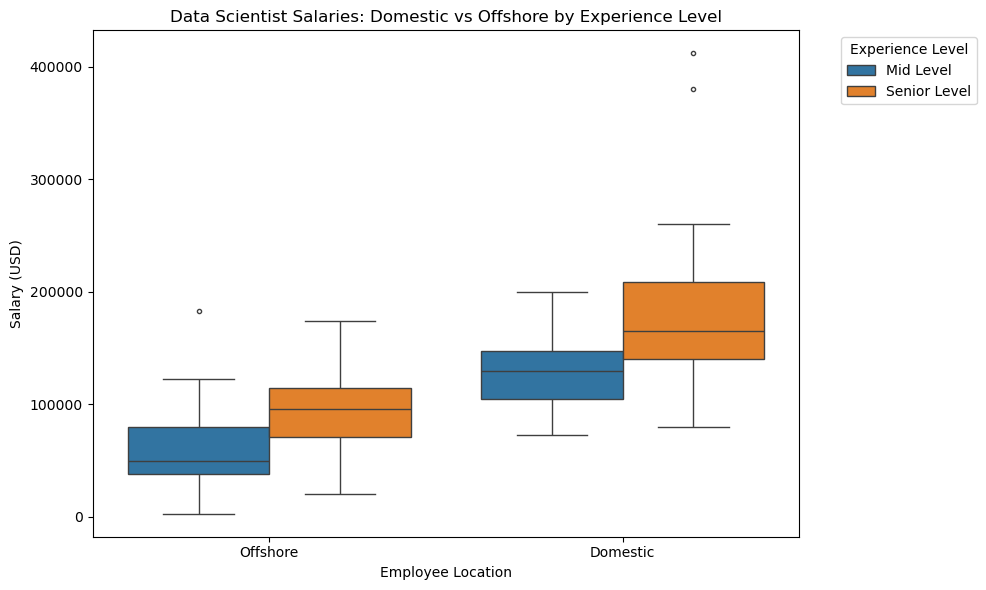

In [33]:
#Finalized table to add experience levels to better compare salary ranges, excluding executive and entry level enployees
ds_df = title_grouped_comp_data[
    (title_grouped_comp_data['job_group'] == "Data Scientist") &
    (~title_grouped_comp_data['experience_level'].isin(["Executive Level", "Entry Level"])) &
    (title_grouped_comp_data['salary_in_usd'] > 0)
].copy()
# Create Domestic vs Offshore group variable
ds_df['location_group'] = ds_df['employee_residence'].apply(lambda x: 'Domestic' if x == 'US' else 'Offshore')
#loops through each salary_currency listing, adds either US/offshore to new col currency "group"
# Remove unused categories so it doesn't show on legend
ds_df['experience_level'] = ds_df['experience_level'].cat.remove_unused_categories()
plt.figure(figsize=(10,6))
sns.boxplot(
    data=ds_df,
    x='location_group',
    y='salary_in_usd',
    hue='experience_level', #color by experience levels
    fliersize=3, # Outlier dot size
    linewidth=1
)
plt.title('Data Scientist Salaries: Domestic vs Offshore by Experience Level')
plt.xlabel('Employee Location')
plt.ylabel('Salary (USD)')
plt.legend(title='Experience Level', bbox_to_anchor=(1.05, 1), loc='upper left')  # move legend off center
plt.tight_layout()
plt.show()
#This looks much better

In [40]:
from IPython.display import display, Markdown
# Display table title
display(Markdown("### Hiring ranges for employees based on location and experience level"))
title_grouped_comp_data['employment_type'] = title_grouped_comp_data['employment_type'].str.strip().str.upper()
ds_df = title_grouped_comp_data[
    (title_grouped_comp_data['job_group'] == "Data Scientist") &
    (title_grouped_comp_data['employment_type'] == "FT") &
    (title_grouped_comp_data['salary_in_usd'] > 0)
].copy()
ds_df = ds_df[ds_df['salary_in_usd'] >= 10000]
ds_df['currency_group'] = ds_df['salary_currency'].apply(lambda x: 'US' if x == 'USD' else 'Offshore')
if hasattr(ds_df['experience_level'], 'cat'):
    ds_df['experience_level'] = ds_df['experience_level'].cat.remove_unused_categories()
salary_summary = (
    ds_df.groupby(['currency_group', 'experience_level'], observed=True)
    .agg(
        count=('salary_in_usd', 'size'),
        min_salary=('salary_in_usd', 'min'),
        max_salary=('salary_in_usd', 'max'),
        mean_salary=('salary_in_usd', 'mean'),
        median_salary=('salary_in_usd', 'median'),
        sd_salary=('salary_in_usd', 'std')
    )
    .reset_index()
)

# Format numbers as dollars
salary_summary[['min_salary', 'max_salary', 'mean_salary', 'median_salary', 'sd_salary']] = \
salary_summary[['min_salary', 'max_salary', 'mean_salary', 'median_salary', 'sd_salary']].map(lambda x: f"${x:,.0f}")

display(salary_summary)

### Hiring ranges for employees based on location and experience level

,currency_group,experience_level,count,min_salary,max_salary,mean_salary,median_salary,sd_salary
0,Offshore,Entry Level,15,"$18,442","$110,037","$55,516","$51,321","$24,566"
1,Offshore,Mid Level,33,"$12,901","$183,228","$63,654","$56,256","$35,838"
2,Offshore,Senior Level,13,"$20,171","$173,762","$96,146","$91,237","$46,255"
3,Offshore,Executive Level,1,"$69,741","$69,741","$69,741","$69,741",$nan
4,US,Entry Level,9,"$13,400","$105,000","$75,156","$90,000","$31,491"
5,US,Mid Level,28,"$45,760","$200,000","$117,286","$119,000","$37,294"
6,US,Senior Level,58,"$80,000","$412,000","$171,959","$165,000","$58,973"


In [41]:
# Display table title
display(Markdown("### Hiring ranges for employees based on location and experience level"))
title_grouped_comp_data['employment_type'] = title_grouped_comp_data['employment_type'].str.strip().str.upper()
ds_df = title_grouped_comp_data[
    (title_grouped_comp_data['job_group'] == "Data Scientist") &
    (title_grouped_comp_data['employment_type'] == "FT") &
    (title_grouped_comp_data['salary_in_usd'] > 0)
].copy()
ds_df['currency_group'] = ds_df['salary_currency'].apply(lambda x: 'US' if x == 'USD' else 'Offshore')
if hasattr(ds_df['experience_level'], 'cat'):
    ds_df['experience_level'] = ds_df['experience_level'].cat.remove_unused_categories()

# Group by currency experience level
salary_summary = (
    ds_df.groupby(['currency_group', 'experience_level'], observed=True)
    .agg(
        count=('salary_in_usd', 'size'),
        min_salary=('salary_in_usd', 'min'),
        max_salary=('salary_in_usd', 'max'),
        mean_salary=('salary_in_usd', 'mean'),
        median_salary=('salary_in_usd', 'median'),
        sd_salary=('salary_in_usd', 'std')
    )
    .reset_index()
)

# Format numbers as dollars
salary_summary[['min_salary', 'max_salary', 'mean_salary', 'median_salary', 'sd_salary']] = \
salary_summary[['min_salary', 'max_salary', 'mean_salary', 'median_salary', 'sd_salary']].map(lambda x: f"${x:,.0f}")

display(salary_summary)

### Hiring ranges for employees based on location and experience level

,currency_group,experience_level,count,min_salary,max_salary,mean_salary,median_salary,sd_salary
0,Offshore,Entry Level,16,"$5,707","$110,037","$52,403","$50,484","$26,802"
1,Offshore,Mid Level,36,"$2,859","$183,228","$58,849","$50,524","$37,895"
2,Offshore,Senior Level,13,"$20,171","$173,762","$96,146","$91,237","$46,255"
3,Offshore,Executive Level,1,"$69,741","$69,741","$69,741","$69,741",$nan
4,US,Entry Level,10,"$4,000","$105,000","$68,040","$85,000","$37,253"
5,US,Mid Level,28,"$45,760","$200,000","$117,286","$119,000","$37,294"
6,US,Senior Level,58,"$80,000","$412,000","$171,959","$165,000","$58,973"


In [33]:
#Table 1- Domestic versus offshore salaries
# Filter for Full-Time Data Scientists with salary and experience level
ds_df = title_grouped_comp_data[
    (title_grouped_comp_data['job_group'] == "Data Scientist") &
    (title_grouped_comp_data['employment_type'] == "FT") &
     (~title_grouped_comp_data['experience_level'].isin(["Executive Level", "Entry Level"])) &
    (title_grouped_comp_data['salary_in_usd'] >0)
].copy()
ds_df['currency_group'] = ds_df['salary_currency'].apply(lambda x: 'US' if x == 'USD' else 'Offshore')
#loops through each salary_currency listing, adds either US/offshore to new col currency "group"
# Remove unused categories so it doesn't show on legend
ds_df['experience_level'] = ds_df['experience_level'].cat.remove_unused_categories()
# Group by currency group and experience level
salary_summary = (
    ds_df.groupby(['currency_group', 'experience_level'], observed=True)
    .agg(
        count=('salary_in_usd', 'size'),
        min_salary=('salary_in_usd', 'min'),
        max_salary=('salary_in_usd', 'max'),
        mean_salary=('salary_in_usd', 'mean'),
        median_salary=('salary_in_usd', 'median'),
        sd_salary=('salary_in_usd', 'std')
    )
    .reset_index()
)
# Format numbers for dollar
salary_summary[['min_salary', 'max_salary', 'mean_salary', 'median_salary', 'sd_salary']] = \
salary_summary[['min_salary', 'max_salary', 'mean_salary', 'median_salary', 'sd_salary']].map(lambda x: f"${x:,.0f}")
#adds $, , seperator w/ 0 decimal places for each lambda loop
salary_summary

,currency_group,experience_level,count,min_salary,max_salary,mean_salary,median_salary,sd_salary
0,Offshore,Entry Level,16,"$5,707","$110,037","$52,403","$50,484","$26,802"
1,Offshore,Mid Level,36,"$2,859","$183,228","$58,849","$50,524","$37,895"
2,Offshore,Senior Level,13,"$20,171","$173,762","$96,146","$91,237","$46,255"
3,Offshore,Executive Level,1,"$69,741","$69,741","$69,741","$69,741",$nan
4,US,Entry Level,10,"$4,000","$105,000","$68,040","$85,000","$37,253"
5,US,Mid Level,28,"$45,760","$200,000","$117,286","$119,000","$37,294"
6,US,Senior Level,58,"$80,000","$412,000","$171,959","$165,000","$58,973"


In [36]:
#Table 2- Salary rates for different company sizes
# Filter for Full-Time Data Scientists with salary and experience level
ds_df = title_grouped_comp_data[
    (title_grouped_comp_data['job_group'] == "Data Scientist") &
    (title_grouped_comp_data['employment_type'] == "FT") &
    (~title_grouped_comp_data['experience_level'].isin(["Executive Level", "Entry Level"])) &
    (title_grouped_comp_data['salary_in_usd'] > 0)
].copy()
ds_df['currency_group'] = ds_df['salary_currency'].apply(lambda x: 'US' if x == 'USD' else 'Offshore')
# Remove unused categories so it doesn't show on legend
ds_df['experience_level'] = ds_df['experience_level'].cat.remove_unused_categories()
# Group by currency group and experience level
salary_summary = (
    ds_df.groupby(['company_size', 'experience_level'], observed=True)
    .agg(
        count=('salary_in_usd', 'size'),
        min_salary=('salary_in_usd', 'min'),
        max_salary=('salary_in_usd', 'max'),
        mean_salary=('salary_in_usd', 'mean'),
        median_salary=('salary_in_usd', 'median'),
        sd_salary=('salary_in_usd', 'std')
    )
    .reset_index()
)
# Format numbers for dollar
salary_summary[['min_salary', 'max_salary', 'mean_salary', 'median_salary', 'sd_salary']] = \
salary_summary[['min_salary', 'max_salary', 'mean_salary', 'median_salary', 'sd_salary']].map(lambda x: f"${x:,.0f}")
#adds $, , seperator w/ 0 decimal places for each lambda loop
salary_summary

,company_size,experience_level,count,min_salary,max_salary,mean_salary,median_salary,sd_salary
0,Small,Mid Level,12,"$2,859","$82,500","$35,957","$33,864","$27,898"
1,Small,Senior Level,3,"$87,738","$190,000","$122,992","$91,237","$58,057"
2,Medium,Mid Level,24,"$33,808","$200,000","$101,014","$96,857","$47,418"
3,Medium,Senior Level,46,"$77,684","$260,000","$156,186","$147,130","$42,759"
4,Large,Mid Level,28,"$31,615","$160,000","$90,956","$90,734","$40,976"
5,Large,Senior Level,22,"$20,171","$412,000","$166,816","$161,600","$95,217"


In [37]:
#T-Test for salaries in USD for domestic versus offshore groups
# Filter for Data Scientist, full-time, salary > 0, exclude Executive and entry levels
ds_df = title_grouped_comp_data[
    (title_grouped_comp_data['job_group'] == "Data Scientist") &
    (title_grouped_comp_data['employment_type'] == "FT") &
    (~title_grouped_comp_data['experience_level'].isin(["Executive Level", "Entry Level"])) &
    (title_grouped_comp_data['salary_in_usd'] > 0)
].copy()
ds_df['location_group'] = ds_df['employee_residence'].apply(lambda x: 'Domestic' if x == 'US' else 'Offshore')
# Separate the two groups domestic & offshore
domestic_salaries = ds_df.loc[ds_df['location_group'] == 'Domestic', 'salary_in_usd']
offshore_salaries = ds_df.loc[ds_df['location_group'] == 'Offshore', 'salary_in_usd']
# Perform Welch's t-test- not assuming equal variance
t_stat, p_value = ttest_ind(domestic_salaries, offshore_salaries, equal_var=False)
print("Welch Two Sample t-test Results")
print(f"t-statistic: {t_stat:.3f}") #f-string; ":"= command, for fixed decimal format w/ 3 digits
print(f"p-value: {p_value:.3e}") #f-string; .3e is command for scientific notation
print(f"Mean Domestic Salary: ${domestic_salaries.mean():,.2f}")
#f-string; ":" starts command to add , sperator for num, ".2f" = fixed decimal format w/ 2 digits 
print(f"Mean Offshore Salary: ${offshore_salaries.mean():,.2f}")

Welch Two Sample t-test Results
t-statistic: 10.664
p-value: 1.675e-19
Mean Domestic Salary: $159,245.06
Mean Offshore Salary: $69,022.87


In [45]:
#T test mid level
ds_df = title_grouped_comp_data[
    (title_grouped_comp_data['job_group'] == "Data Scientist") &
    (title_grouped_comp_data['employment_type'] == "FT") &
    (title_grouped_comp_data['experience_level'].isin(["Mid Level"])) &
    (title_grouped_comp_data['salary_in_usd'] > 0)
].copy()
ds_df['location_group'] = ds_df['employee_residence'].apply(lambda x: 'Domestic' if x == 'US' else 'Offshore')
# Separate the two groups domestic & offshore
domestic_salaries = ds_df.loc[ds_df['location_group'] == 'Domestic', 'salary_in_usd']
offshore_salaries = ds_df.loc[ds_df['location_group'] == 'Offshore', 'salary_in_usd']
# Perform Welch's t-test- not assuming equal variance
t_stat, p_value = ttest_ind(domestic_salaries, offshore_salaries, equal_var=False)
print("Welch Two Sample t-test Results for Mid Level Employees")
print(f"t-statistic Mid Level: {t_stat:.3f}") #f-string; ":"= command, for fixed decimal format w/ 3 digits
print(f"p-value Mid Level: {p_value:.3e}") #f-string; .3e is command for scientific notation
print(f"Mean Domestic Mid Level Salary: ${domestic_salaries.mean():,.2f}")
#f-string; ":" starts command to add , sperator for num, ".2f" = fixed decimal format w/ 2 digits 
print(f"Mean Offshore Mid Level Salary: ${offshore_salaries.mean():,.2f}")

Welch Two Sample t-test Results for Mid Level Employees
t-statistic Mid Level: 7.798
p-value Mid Level: 1.645e-10
Mean Domestic Mid Level Salary: $126,052.08
Mean Offshore Mid Level Salary: $59,433.40


In [46]:
#T test Senior level
ds_df = title_grouped_comp_data[
    (title_grouped_comp_data['job_group'] == "Data Scientist") &
    (title_grouped_comp_data['employment_type'] == "FT") &
    (title_grouped_comp_data['experience_level'].isin(["Senior Level"])) &
    (title_grouped_comp_data['salary_in_usd'] > 0)
].copy()
ds_df['location_group'] = ds_df['employee_residence'].apply(lambda x: 'Domestic' if x == 'US' else 'Offshore')
# Separate the two groups domestic & offshore
domestic_salaries = ds_df.loc[ds_df['location_group'] == 'Domestic', 'salary_in_usd']
offshore_salaries = ds_df.loc[ds_df['location_group'] == 'Offshore', 'salary_in_usd']
# Perform Welch's t-test- not assuming equal variance
t_stat, p_value = ttest_ind(domestic_salaries, offshore_salaries, equal_var=False)
print("Welch Two Sample t-test Results for Senior Level Employees")
print(f"t-statistic Senior Level: {t_stat:.3f}") #f-string; ":"= command, for fixed decimal format w/ 3 digits
print(f"p-value Senior Level: {p_value:.3e}") #f-string; .3e is command for scientific notation
print(f"Mean Domestic Senior Level Salary: ${domestic_salaries.mean():,.2f}")
#f-string; ":" starts command to add , sperator for num, ".2f" = fixed decimal format w/ 2 digits 
print(f"Mean Offshore Senior Level Salary: ${offshore_salaries.mean():,.2f}")

Welch Two Sample t-test Results for Senior Level Employees
t-statistic Senior Level: 5.409
p-value Senior Level: 1.228e-05
Mean Domestic Senior Level Salary: $173,221.05
Mean Offshore Senior Level Salary: $96,421.36


In [ ]:
#T is large suggesting that there is a large difference between the two groups. P-value is very small,
#so that means that there is a very small chance that there is not a difference between the two groups.
#The difference in the means of the two groups is statistically significant. I can report back to the 
#CEO that it would be cheaper to higher an offshore employee; based on these t-test results, we have 
#reason to believe that the cost would be much cheaper. Cost of the employee could potentially be 
#reduced by half.

In [44]:
#Salary Ranges
ds_df = title_grouped_comp_data[
    (title_grouped_comp_data['job_group'] == "Data Scientist") &
    (title_grouped_comp_data['employment_type'] == "FT") &
    (title_grouped_comp_data['experience_level'].isin(["Mid Level", "Senior Level"])) &
    (title_grouped_comp_data['salary_in_usd'] > 0)
].copy()
# Create Domestic vs Offshore grouping
ds_df['currency_group'] = ds_df['salary_currency'].apply(
    lambda x: 'US' if x == 'USD' else 'Offshore'
)
ds_df['experience_level'] = ds_df['experience_level'].cat.remove_unused_categories()
# Group and calculate percentiles
salary_summary = (
    ds_df.groupby(['currency_group', 'experience_level'], observed=True)
    .agg(
        count=('salary_in_usd', 'size'),
        Quartile_One_salary=('salary_in_usd', lambda x: x.quantile(0.25)),
        median_salary=('salary_in_usd', 'median'),
        Quartile_Three_salary=('salary_in_usd', lambda x: x.quantile(0.75))
    )
    .reset_index()
)
# Format as dollars
salary_summary[['Quartile_One_salary', 'median_salary', 'Quartile_Three_salary']] = \
    salary_summary[['Quartile_One_salary', 'median_salary', 'Quartile_Three_salary']] \
    .map(lambda x: f"${x:,.0f}") #adds $, , seperator w/ 0 decimal places for each lambda loop
salary_summary

,currency_group,experience_level,count,Quartile_One_salary,median_salary,Quartile_Three_salary
0,Offshore,Mid Level,36,"$35,699","$50,524","$77,677"
1,Offshore,Senior Level,13,"$68,428","$91,237","$117,789"
2,US,Mid Level,28,"$99,075","$119,000","$142,725"
3,US,Senior Level,58,"$140,000","$165,000","$208,825"
